In [1]:
import pandas as pd
import requests
import io
import missingno as msno

In [2]:
URL = "https://data.wa.gov/resource/f6w7-q2d2.csv"

LIMIT = 100_000
OFFSET = 0

chunks = []

with requests.Session() as session:
    while True:
        response = session.get(
            URL,
            params={
                "$limit": LIMIT,
                "$offset": OFFSET,
            },
            timeout=600,
        )
        response.raise_for_status()

        chunk = pd.read_csv(io.BytesIO(response.content))

        if chunk.empty:
            print("No more rows to download.")
            break

        chunks.append(chunk)

        OFFSET += len(chunk)

        print(f"Retrieved {OFFSET:,} rows")

        if len(chunk) < LIMIT:
            print("No more rows to download.")
            break

df = pd.concat(chunks, ignore_index=True)

Retrieved 100,000 rows
Retrieved 200,000 rows
Retrieved 294,193 rows
No more rows to download.


In [3]:
pd.set_option('display.max_rows', 1000)

<Axes: >

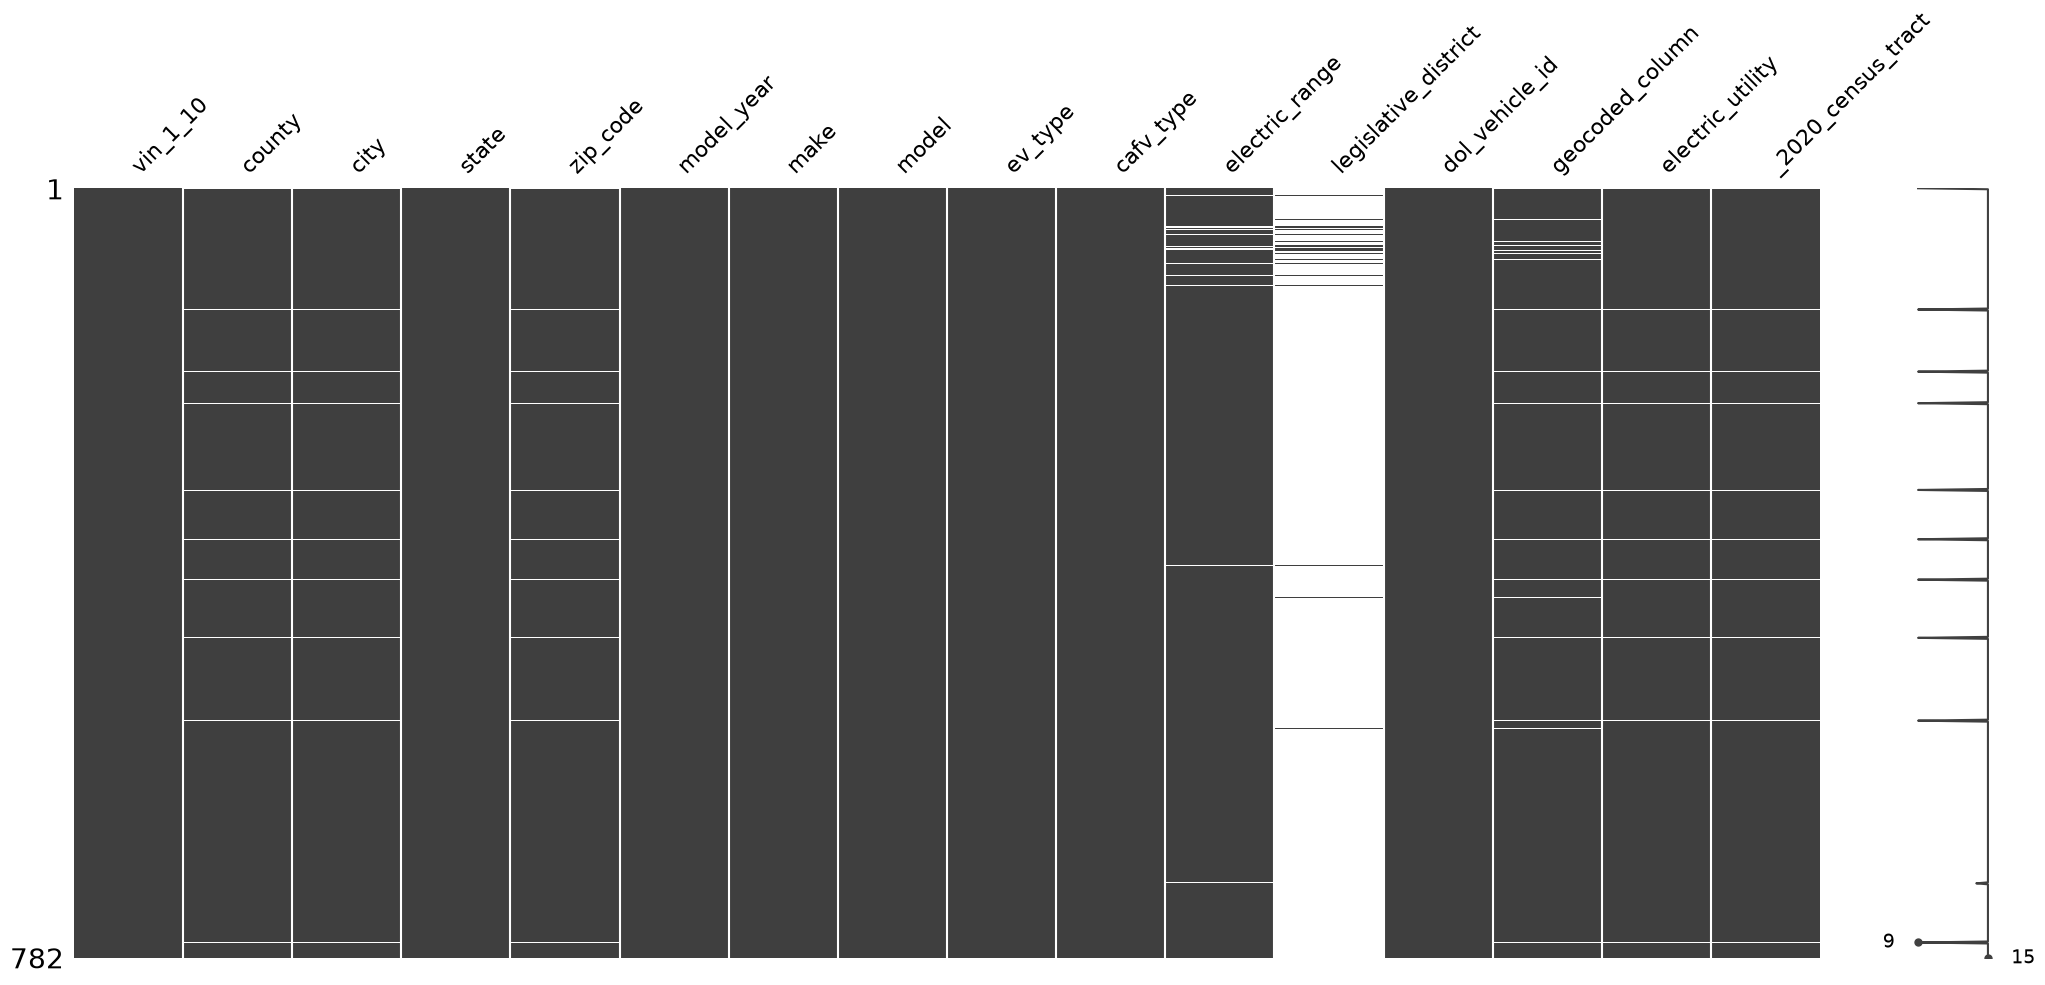

In [4]:
msno.matrix(df[df.isnull().any(axis=1)])

In [5]:
df[df.isnull().any(axis=1)]

,vin_1_10,county,city,state,zip_code,model_year,make,model,ev_type,cafv_type,electric_range,legislative_district,dol_vehicle_id,geocoded_column,electric_utility,_2020_census_tract
372,1G1FX6S08J,NaN,NaN,BC,NaN,2018,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238.0,NaN,272897614,NaN,NaN,NaN
20191,WBAJA9C56J,Multnomah,Fairview,OR,97024.0,2018,BMW,530E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,16.0,NaN,145668274,POINT (-122.4395 45.5324),NON WASHINGTON STATE ELECTRIC UTILITY,4.105101e+10
39174,7G2CEHEDXS,Leavenworth,Fort Leavenworth,KS,66027.0,2025,TESLA,CYBERTRUCK,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,NaN,284708406,POINT (-94.92007 39.35344),NON WASHINGTON STATE ELECTRIC UTILITY,2.010398e+10
41421,7SAYGAEE9N,Santa Clara,Milpitas,CA,95035.0,2022,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,NaN,220637546,POINT (-121.89694 37.43288),NON WASHINGTON STATE ELECTRIC UTILITY,6.085505e+09
44017,5YJ3E1EA5K,Fresno,Fresno,CA,93720.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,NaN,176537112,POINT (-119.75611 36.86529),NON WASHINGTON STATE ELECTRIC UTILITY,6.019006e+09
52123,WBY43EJ02R,Contra Costa,Martinez,CA,94553.0,2024,BMW,I7,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,NaN,284065750,POINT (-122.13494 38.01393),NON WASHINGTON STATE ELECTRIC UTILITY,6.013318e+09
54055,3FA6P0SU4F,Carroll,Westminster,MD,21157.0,2015,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19.0,NaN,120552358,POINT (-76.99225 39.57467),NON WASHINGTON STATE ELECTRIC UTILITY,2.401351e+10
54695,ZHWUC1ZM0T,King,Bellevue,WA,98005.0,2026,LAMBORGHINI,REVUELTO,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,NaN,48.0,293647504,POINT (-122.1621 47.64441),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
56146,KNDC3DLC5N,Saratoga,Ballston Spa,NY,12020.0,2022,KIA,EV6,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,NaN,192662011,POINT (-73.85124 43.00242),NON WASHINGTON STATE ELECTRIC UTILITY,3.609106e+10
57399,JN1DF0BB8R,Multnomah,Troutdale,OR,97060.0,2024,NISSAN,ARIYA HATCHBACK,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,NaN,272586380,POINT (-122.38535 45.54038),NON WASHINGTON STATE ELECTRIC UTILITY,4.105101e+10


In [6]:
df.isnull().sum()

vin_1_10                  0
county                   10
city                     10
state                     0
zip_code                 10
model_year                0
make                      0
model                     0
ev_type                   0
cafv_type                 0
electric_range           13
legislative_district    762
dol_vehicle_id            0
geocoded_column          18
electric_utility         10
_2020_census_tract       10
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 294193 entries, 0 to 294192
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   vin_1_10              294193 non-null  str    
 1   county                294183 non-null  str    
 2   city                  294183 non-null  str    
 3   state                 294193 non-null  str    
 4   zip_code              294183 non-null  float64
 5   model_year            294193 non-null  int64  
 6   make                  294193 non-null  str    
 7   model                 294193 non-null  str    
 8   ev_type               294193 non-null  str    
 9   cafv_type             294193 non-null  str    
 10  electric_range        294180 non-null  float64
 11  legislative_district  293431 non-null  float64
 12  dol_vehicle_id        294193 non-null  int64  
 13  geocoded_column       294175 non-null  str    
 14  electric_utility      294183 non-null  str    
 15  _2020_censu

In [8]:
df.duplicated(subset=['vin_1_10']).sum()

np.int64(276125)

In [20]:
((df.isnull().any(axis=1).sum() / len(df)) * 100.0).round(2)

np.float64(0.27)

In [21]:
null_df = df[df.isnull().any(axis=1)]

In [23]:
clean_df = df[~df.isnull().any(axis=1)]

In [27]:
df_state = set(df['state'].unique())

In [24]:
states = us_states_and_territories = {
    # 50 States
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA",
    "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD",
    "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ",
    "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC",
    "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY",

    # District of Columbia
    "DC",

    # U.S. Territories
    "AS",  # American Samoa
    "GU",  # Guam
    "MP",  # Northern Mariana Islands
    "PR",  # Puerto Rico
    "VI",  # U.S. Virgin Islands
    "UM"  # U.S. Minor Outlying Islands
}

In [28]:
df_state - states

{'AE', 'BC', 'QC'}

In [30]:
df[df['state'].isin(df_state - states)]

,vin_1_10,county,city,state,zip_code,model_year,make,model,ev_type,cafv_type,electric_range,legislative_district,dol_vehicle_id,geocoded_column,electric_utility,_2020_census_tract
372,1G1FX6S08J,NaN,NaN,BC,NaN,2018,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238.0,NaN,272897614,NaN,NaN,NaN
243135,5YJ3E1EA6K,NaN,NaN,BC,NaN,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,NaN,323559204,NaN,NaN,NaN
252984,3FA6P0SU7E,NaN,NaN,AE,NaN,2014,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19.0,NaN,255045136,NaN,NaN,NaN
257860,WVGTMPE23M,NaN,NaN,AE,NaN,2021,VOLKSWAGEN,ID.4,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,NaN,179339058,NaN,NaN,NaN
265661,5YJ3E1EA5S,NaN,NaN,BC,NaN,2025,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,NaN,280877355,NaN,NaN,NaN
269448,7SAYGDEF8N,NaN,NaN,QC,NaN,2022,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,NaN,211959226,NaN,NaN,NaN
272169,7SAYGDEE9N,NaN,NaN,BC,NaN,2022,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,NaN,224286394,NaN,NaN,NaN
276895,5YJXCAE24H,NaN,NaN,BC,NaN,2017,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200.0,NaN,159850029,NaN,NaN,NaN
293578,JTDKAMFP9N,NaN,NaN,AE,NaN,2022,TOYOTA,PRIUS PRIME (PHEV),Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25.0,NaN,198537741,NaN,NaN,NaN


In [38]:
set(df.ev_type.unique())

{'Battery Electric Vehicle (BEV)', 'Plug-in Hybrid Electric Vehicle (PHEV)'}

In [36]:
set(df.cafv_type.unique())

{'Clean Alternative Fuel Vehicle Eligible',
 'Eligibility unknown as battery range has not been researched',
 'Not eligible due to low battery range'}

In [37]:
fuel_type={'Clean Alternative Fuel Vehicle Eligible',
 'Eligibility unknown as battery range has not been researched',
 'Not eligible due to low battery range'}

In [39]:
ev_type={'Battery Electric Vehicle (BEV)', 'Plug-in Hybrid Electric Vehicle (PHEV)'}